In [1]:
#Google Sheets Linking (Needs user authorization)
from google.colab import auth
auth.authenticate_user()

import gspread
from google.auth import default
creds, _ = default()

gc = gspread.authorize(creds)

In [2]:
import pandas as pd

# Open the spreadsheet by URL
spreadsheet_url = 'https://docs.google.com/spreadsheets/d/14pMQzQwy2Dl9OIhS24hyJdX1sfEdVi9SeZfGuYaMKQ0/edit?usp=drive_link'
wb = gc.open_by_url(spreadsheet_url)
sheet = wb.get_worksheet(0)

# Load data into DataFrame
data = sheet.get_all_values()
df = pd.DataFrame(data[1:], columns=data[0])

print("Original Data:")
display(df.head())


Original Data:


,text,label_specific,label_generic
0,Hi\n\n I am running the IR test...,human_legit,legit
1,\n\n\n\n\n\n\n\n\n\n\n\n\nSecurity Note: Trade...,human_legit,legit
2,\n\n\n\n\n\n\n\n\n\nTrade Me Offer RequestGene...,human_legit,legit
3,"Hi Tony\nNot sure why it didn't work, but I ma...",human_legit,legit
4,Kindly suggest changes\n\n--------------------...,human_legit,legit


In [3]:
import re
from sklearn.feature_extraction.text import TfidfVectorizer

def preprocessing(text):
  #collapse spaces to make the text more concise
  text = re.sub(r'\s+', ' ', text)

  #Tokenize links + emails
  text = re.sub(r'http\S+', 'URL_TOKEN', text)
  text = re.sub(r'\S*@\S*\s?', 'EMAIL_TOKEN', text)

  #regex to keep alphabetic characters, both capitalized and lowercase, numbers, spaces, . , ! ? ' \ " < > : + = \ ( ) $ %
  #& ^ * # _ - safe. This removes emojis or foreign characters.
  pattern = r"[^a-zA-Z0-9\s.,!?/'\"<>:+=\\()$@;\[\]|%&^*#_`{}~-]"
  text = re.sub(pattern, " ", text);

  pattern2 = r"\b(monkey|jose|org|spambayes)\b"
  text = re.sub(pattern2, " ", text);

  pattern3 = r"\b20\d{2}\b"
  text = re.sub(pattern3, " ", text);

  return text.strip()

df_processed = df.copy()
for col in df_processed.columns:
    df_processed[col] = df_processed[col].apply(preprocessing)

print("Processed Data:")

# Set display options to show all rows and columns
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', None)

# EDA work
display(df_processed)

# create csv
df_processed.to_csv("DBLT2_preprocessed.csv", index=False)


Output hidden; open in https://colab.research.google.com to view.

In [ ]:
#Average word count per message per category
df_processed['word_count'] = df_processed['text'].str.split().str.len()

average_word_count = df_processed.groupby('label')['word_count'].mean().reset_index()

print("Average word count per label:")
display(average_word_count)

Average word count per label:


,label,word_count
0,human_legit,199.375000
1,human_phishing,259.814815
2,llm_legit,92.666667
3,llm_phishing,102.235294


In [ ]:
#display the average character length per message per category
df_processed['message_length'] = df_processed['text'].apply(len)

average_message_length = df_processed.groupby('label')['message_length'].mean().reset_index()

print("Average message length per label:")
display(average_message_length)

Average message length per label:


,label,message_length
0,human_legit,1208.375000
1,human_phishing,1655.074074
2,llm_legit,564.238095
3,llm_phishing,645.411765


In [ ]:
def count_url_tokens(text):
  text = str(text)

  url_pattern = r'URL_TOKEN'

  tokens = re.findall(url_pattern, text)
  return len(tokens)

In [ ]:
def count_url_links(text):
  text = str(text)
  url_pattern = r'(httos?://\S+|www\.\S+)'
  urls=re.findall(url_pattern,text)
  return len(urls)

In [ ]:
#display the average number of urls per message per category
df_processed['url_count'] = df_processed['text'].apply(count_url_tokens)

average_number_urls = df_processed.groupby('label')['url_count'].mean().reset_index()

print("Average Number of URLs:")
display(average_number_urls)

Average Number of URLs:


,label,url_count
0,human_legit,1.12500
1,human_phishing,0.00000
2,llm_legit,0.47619
3,llm_phishing,1.00000


In [ ]:
df_processed['text'].apply(count_url_links)

df_processed['url_count'] = df_processed['text'].apply(count_url_links)
labels_to_keep = ['human_legit', 'human_phishing', 'llm_legit', 'llm_phishing']
df_sub = df_processed[df_processed['label'].isin(labels_to_keep)].copy()
url_table = pd.crosstab(df_sub['label'], df_sub['url_count'])
print("URL Count Frequency Table (rows=label, cols=url_count):")
display(url_table)

URL Count Frequency Table (rows=label, cols=url_count):


url_count,0,1,2,4
label,,,,
human_legit,8,0,0,0
human_phishing,22,1,2,2
llm_legit,21,0,0,0
llm_phishing,17,0,0,0


In [ ]:
def count_email_tokens(text):
  text = str(text)

  email_pattern = r'EMAIL_TOKEN'

  tokens = re.findall(email_pattern, text)
  return len(tokens)

In [ ]:
def count_num_email_(text):
  text = str(text)
  emails=re.findall('EMAIL_TOKEN',text)
  return len(emails)

Total Number of Emails:


,label,email_count
0,human_legit,11
1,human_phishing,24
2,llm_legit,0
3,llm_phishing,0


Text(0.5, 0, 'Total Email Amount')

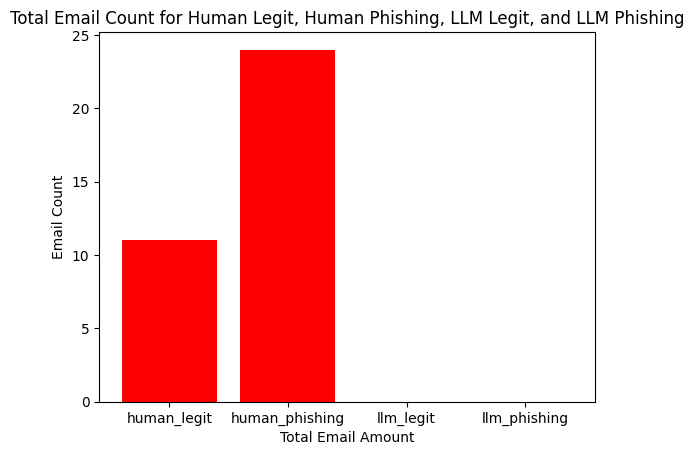

In [ ]:
import matplotlib.pyplot as plt

df_processed['email_count'] = df_processed['text'].apply(count_email_tokens)

total_number_emails = df_processed.groupby('label')['email_count'].sum().reset_index()
numberEmails = df_processed['email_count']

print("Total Number of Emails:")
display(total_number_emails)
label = ['human_legit', 'human_phishing', 'llm_legit', 'llm_phishing']
plt.bar(label, total_number_emails['email_count'], color='red')
plt.title('Total Email Count for Human Legit, Human Phishing, LLM Legit, and LLM Phishing')
plt.ylabel('Email Count')
plt.xlabel('Total Email Amount')

In [ ]:
df_processed['text'].apply(count_num_email_)

df_processed['email_count'] = df_processed['text'].apply(count_num_email_)
labels_to_keep = ['human_legit', 'human_phishing', 'llm_legit', 'llm_phishing']
df_sub = df_processed[df_processed['label'].isin(labels_to_keep)].copy()
email_table = pd.crosstab(df_sub['label'], df_sub['email_count'])
print("Email Count Frequency Table (rows=label, cols=url_count):")
display(email_table)

Email Count Frequency Table (rows=label, cols=url_count):


email_count,0,1,2,3,4
label,,,,,
human_legit,1,4,2,1,0
human_phishing,13,10,0,2,2
llm_legit,21,0,0,0,0
llm_phishing,17,0,0,0,0


In [ ]:
import plotly.express as px
message_word_fig = px.density_heatmap(df_processed, x='message_length', y='word_count')
message_word_fig.show()

In [ ]:
# KNN model importing libraries
from sklearn.neighbors import NearestNeighbors
import numpy as np
X = df_processed.email_count
nbrs = NearestNeighbors(n_neighbors=3, algorithm='ball_tree').fit(X)

ValueError: Expected a 2-dimensional container but got <class 'pandas.core.series.Series'> instead. Pass a DataFrame containing a single row (i.e. single sample) or a single column (i.e. single feature) instead.